# 🌸 Iris Flower Classification using Machine Learning

Complete ML workflow: EDA → preprocessing → train/test split → model training → evaluation → comparison.

## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Dataset

In [3]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Data Exploration

In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## 4. Data Visualization

### Pair Plot

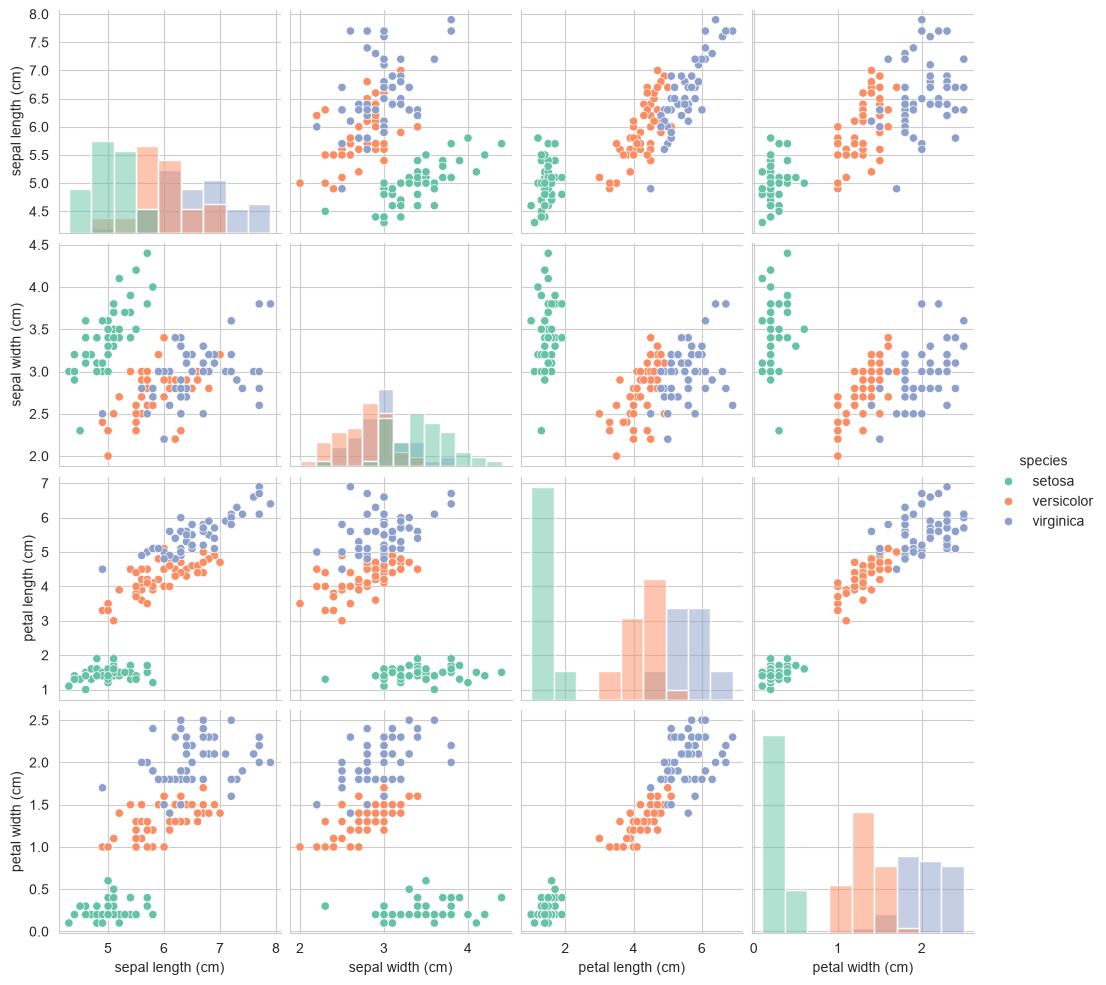

In [9]:
sns.pairplot(df, hue="species", diag_kind="hist", palette="Set2")
plt.show()

### Correlation Heatmap

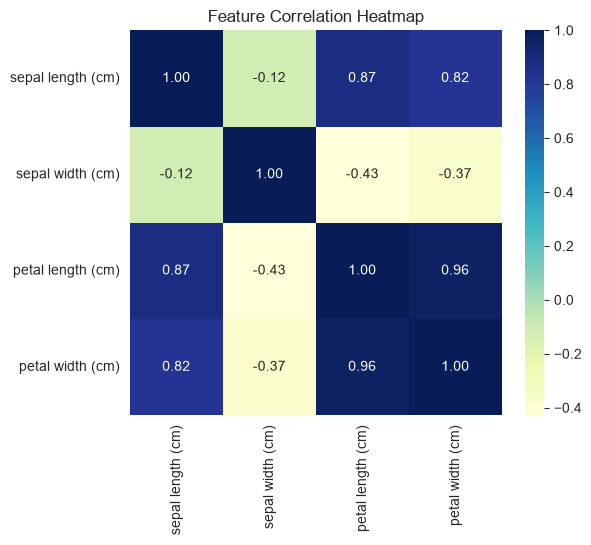

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(df.drop(columns=["species"]).corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Histograms

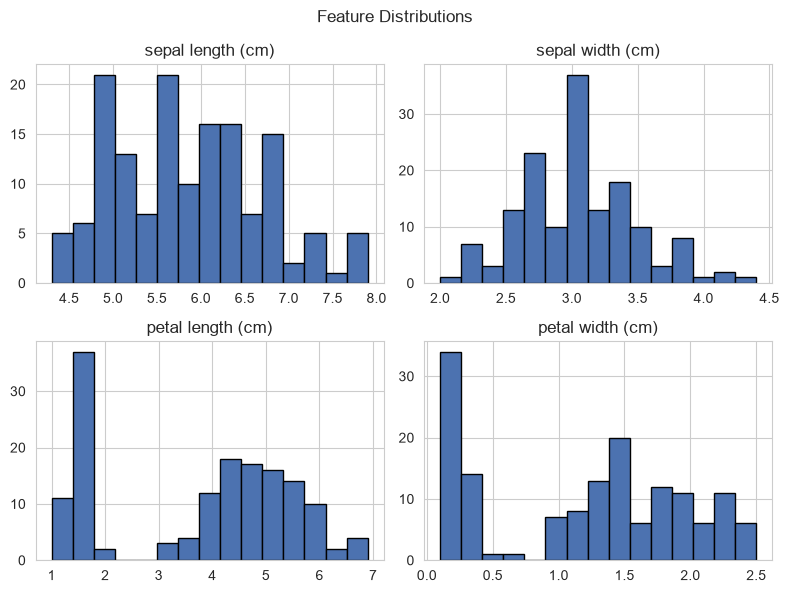

In [11]:
df.drop(columns=["species"]).hist(figsize=(8,6), bins=15, color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

### Box Plots

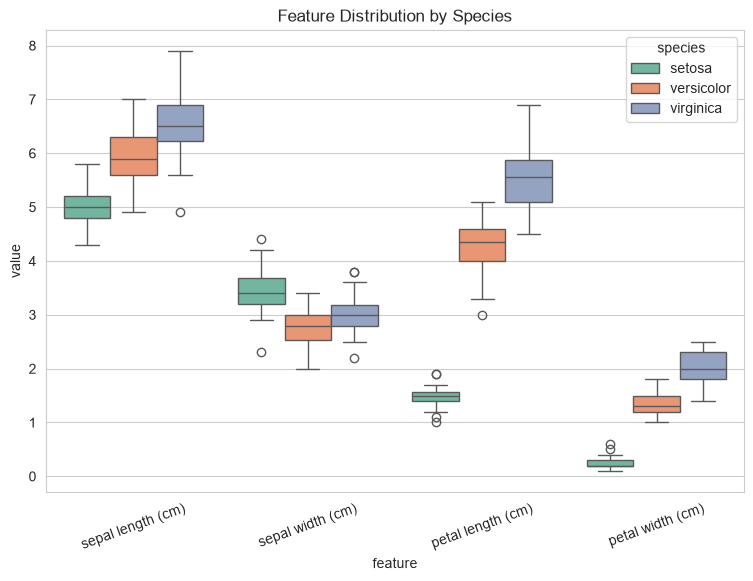

In [12]:
melted = df.melt(id_vars="species", var_name="feature", value_name="value")
plt.figure(figsize=(9,6))
sns.boxplot(data=melted, x="feature", y="value", hue="species", palette="Set2")
plt.title("Feature Distribution by Species")
plt.xticks(rotation=20)
plt.show()

## 5. Data Preprocessing

In [13]:
X = df.drop(columns=["species"])
y = df["species"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 6. Train-Test Split (80/20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (120, 4)  Test size: (30, 4)


## 7. Model Training

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
print("All models trained.")

All models trained.


## 8. Model Evaluation

In [16]:
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "accuracy": acc,
        "report": classification_report(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred, labels=model.classes_),
    }
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(results[name]["report"])

=== Logistic Regression ===
Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

=== Decision Tree ===
Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

=== Random Forest ===
Accuracy: 0.9000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  vers

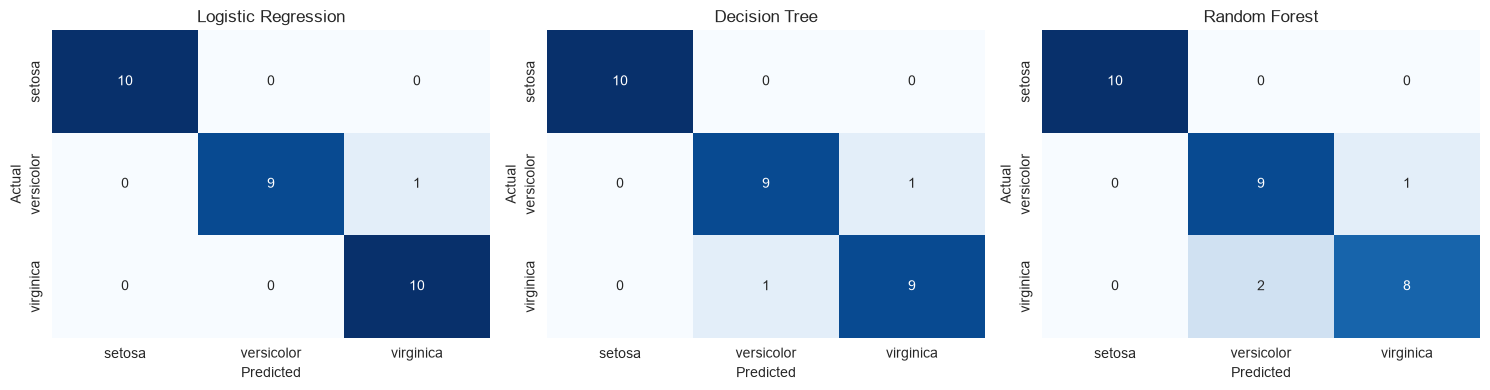

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 9. Model Comparison

In [18]:
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [r["accuracy"] for r in results.values()]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy
0,Logistic Regression,0.966667
1,Decision Tree,0.933333
2,Random Forest,0.900000


In [19]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name} (Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f})")

import joblib
joblib.dump(best_model, "iris_model.pkl")
print("Saved best model to iris_model.pkl")

Best model: Logistic Regression (Accuracy: 0.9667)
Saved best model to iris_model.pkl
